In [13]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 106.0 MB/s  0:00:00


In [12]:
pip install ultralytics==8.4.152

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.7 MB/s  0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.4.153
    Uninstalling ultralytics-8.4.153:
      Successfully uninstalled ultralytics-8.4.153
Note: you may need to restart the kernel to use updated packages.


In [15]:
from ultralytics import YOLO
import os
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
DATA_ROOT = "/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced"
DATA_YAML = f"{DATA_ROOT}/data.yaml"

RUNS_ROOT = "/workspace/runs/cardd"
EXP_NAME = "experiment_7_yolo11m"

BEST_MODEL = f"{RUNS_ROOT}/{EXP_NAME}/weights/best.pt"

print("Dataset:", DATA_ROOT)
print("YAML:", DATA_YAML)
print("Best model:", BEST_MODEL)

Dataset: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced
YAML: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml
Best model: /workspace/runs/cardd/experiment_7_yolo11m/weights/best.pt


In [33]:
import os

DATA_ROOT = "/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced"

print("DATA ROOT:", DATA_ROOT)
print("Exists:", os.path.exists(DATA_ROOT))

for split in ["train", "val", "test"]:
    img_dir = os.path.join(DATA_ROOT, "images", split)
    lbl_dir = os.path.join(DATA_ROOT, "labels", split)
import os

print("Contents of /workspace:")
print(os.listdir("/workspace"))

print("\nFolders under /workspace:")
for name in os.listdir("/workspace"):
    path = os.path.join("/workspace", name)
    if os.path.isdir(path):
        print("📁", path)

DATA ROOT: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced
Exists: False
Contents of /workspace:
['.cache', 'Untitled.ipynb', '.ipynb_checkpoints', 'CarDD_YOLO_Reduced.zip', 'Untitled1.ipynb']

Folders under /workspace:
📁 /workspace/.cache
📁 /workspace/.ipynb_checkpoints


In [34]:
import zipfile
import os

ZIP_PATH = "/workspace/CarDD_YOLO_Reduced.zip"
EXTRACT_PATH = "/workspace/CarDD_YOLO_Reduced"

print("ZIP exists:", os.path.exists(ZIP_PATH))

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✓ Extraction completed")
print("\nContents:")
print(os.listdir(EXTRACT_PATH))

ZIP exists: True
✓ Extraction completed

Contents:
['CarDD_YOLO_Reduced']


In [35]:
import os

for root, dirs, files in os.walk("/workspace/CarDD_YOLO_Reduced"):
    level = root.replace("/workspace/CarDD_YOLO_Reduced", "").count(os.sep)
    if level <= 2:
        print("  " * level + "📁 " + root)
        for f in files[:5]:
            print("  " * (level + 1) + "📄 " + f)

📁 /workspace/CarDD_YOLO_Reduced
  📁 /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced
    📄 data.yaml
    📁 /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/images
    📁 /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/labels


In [42]:
from pathlib import Path

DATA_ROOT = Path("/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced")
DATA_YAML = DATA_ROOT / "data.yaml"

yaml_content = """path: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced
train: images/train
val: images/val
test: images/test

names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat
"""

DATA_YAML.write_text(yaml_content)

print(DATA_YAML)
print(DATA_YAML.read_text())

/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml
path: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced
train: images/train
val: images/val
test: images/test

names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat



In [36]:
import os

DATA_ROOT = "/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced"
DATA_YAML = f"{DATA_ROOT}/data.yaml"

for split in ["train", "val", "test"]:
    img_dir = os.path.join(DATA_ROOT, "images", split)
    lbl_dir = os.path.join(DATA_ROOT, "labels", split)

    images = [
        f for f in os.listdir(img_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    labels = [
        f for f in os.listdir(lbl_dir)
        if f.lower().endswith(".txt")
    ]

    print(f"{split}:")
    print(f"  Images: {len(images)}")
    print(f"  Labels: {len(labels)}")

print("\nDATA_YAML:")
print(DATA_YAML)
print("YAML exists:", os.path.exists(DATA_YAML))

train:
  Images: 1408
  Labels: 1408
val:
  Images: 810
  Labels: 810
test:
  Images: 374
  Labels: 374

DATA_YAML:
/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml
YAML exists: True


In [37]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

PyTorch: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA A40
GPU memory: 44.42 GB


In [38]:
model = YOLO("yolo11m.pt")

print("YOLO11m loaded successfully.")

YOLO11m loaded successfully.


In [39]:
model = YOLO("yolo11m.pt")

print("YOLO11m loaded successfully.")

YOLO11m loaded successfully.


In [43]:
EPOCHS = 100
IMGSZ = 640
BATCH = 16
WORKERS = 4

print("Experiment:", EXP_NAME)
print("Epochs:", EPOCHS)
print("Image size:", IMGSZ)
print("Batch:", BATCH)

Experiment: experiment_7_yolo11m
Epochs: 100
Image size: 640
Batch: 16


In [ ]:
results = model.train(
    data=DATA_YAML,

    # Training
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,

    # Reproducibility
    seed=42,
    deterministic=True,

    # Optimizer
    optimizer="auto",

    # AMP
    amp=True,

    # Augmentation — same as Exp6
    degrees=5.0,
    translate=0.15,
    scale=0.60,
    fliplr=0.50,
    flipud=0.0,
    mosaic=1.0,
    mixup=0.10,
    copy_paste=0.10,

    # Output
    project=RUNS_ROOT,
    name=EXP_NAME,
    exist_ok=True
)

print("Training completed.")

In [46]:
from pathlib import Path

best_path = Path(BEST_MODEL)
last_path = best_path.parent / "last.pt"

print("Best exists:", best_path.exists())
print("Last exists:", last_path.exists())

print("\nBest:", best_path)
print("Last:", last_path)

Best exists: True
Last exists: True

Best: /workspace/runs/cardd/experiment_7_yolo11m/weights/best.pt
Last: /workspace/runs/cardd/experiment_7_yolo11m/weights/last.pt


In [47]:
best_model = YOLO(str(BEST_MODEL))

print("Best YOLO11m model loaded.")

Best YOLO11m model loaded.


In [48]:
val_results = best_model.val(
    data=DATA_YAML,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.153 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA A40, 45488MiB)
YOLO11m summary (fused): 125 layers, 20,034,658 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2977.2±1828.2 MB/s, size: 764.5 KB)
val: Scanning /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/labels/val.cache... 810 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 810/810 261.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 8.0it/s 6.4s0.1s
                   all        810       1744       0.68      0.642      0.653      0.489
                  dent        352        501      0.589      0.409      0.449      0.235
               scratch        431        728      0.459      0.532      0.458      0.233
                 crack        122        177      0.461      0.288      0.279      0.116
         glass shatter        134        135      0.964      0.956      0.984      0.863
      

In [49]:
print("Overall Validation Results")
print("-" * 40)

print("Precision :", round(val_results.box.mp, 4))
print("Recall    :", round(val_results.box.mr, 4))
print("mAP50     :", round(val_results.box.map50, 4))
print("mAP50-95  :", round(val_results.box.map, 4))

Overall Validation Results
----------------------------------------
Precision : 0.6798
Recall    : 0.6419
mAP50     : 0.6532
mAP50-95  : 0.4892


In [54]:
comparison = pd.DataFrame([
    {
        "Experiment": "Exp3 - YOLO11n",
        "Precision": 0.7404,
        "Recall": 0.6081,
        "mAP50": 0.6538,
        "mAP50-95": 0.5005
    },
    {
        "Experiment": "Exp6 - YOLO11s",
        "Precision": 0.733,
        "Recall": 0.668,
        "mAP50": 0.688,
        "mAP50-95": 0.531
    },
    {
        "Experiment": "Exp7 - YOLO11m",
        "Precision": val_results.box.mp,
        "Recall": val_results.box.mr,
        "mAP50": val_results.box.map50,
        "mAP50-95": val_results.box.map
    }
])

comparison

,Experiment,Precision,Recall,mAP50,mAP50-95
0,Exp3 - YOLO11n,0.740400,0.608100,0.653800,0.500500
1,Exp6 - YOLO11s,0.733000,0.668000,0.688000,0.531000
2,Exp7 - YOLO11m,0.679809,0.641905,0.653238,0.489243


In [55]:
comparison.sort_values(
    "mAP50-95",
    ascending=False
).reset_index(drop=True)

,Experiment,Precision,Recall,mAP50,mAP50-95
0,Exp6 - YOLO11s,0.733000,0.668000,0.688000,0.531000
1,Exp3 - YOLO11n,0.740400,0.608100,0.653800,0.500500
2,Exp7 - YOLO11m,0.679809,0.641905,0.653238,0.489243


In [60]:
names = best_model.names

print(f"{'Class':<20} {'P':>8} {'R':>8} {'mAP50':>10} {'mAP50-95':>12}")
print("-" * 65)

for i, name in names.items():
    print(
        f"{name:<20} "
        f"{val_results.box.p[i]:>8.3f} "
        f"{val_results.box.r[i]:>8.3f} "
        f"{val_results.box.ap50[i]:>10.3f} "
        f"{val_results.box.ap[i]:>12.3f}"
    )

Class                       P        R      mAP50     mAP50-95
-----------------------------------------------------------------
dent                    0.589    0.409      0.449        0.235
scratch                 0.459    0.532      0.458        0.233
crack                   0.461    0.288      0.279        0.116
glass shatter           0.964    0.956      0.984        0.863
lamp broken             0.747    0.731      0.811        0.652
tire flat               0.858    0.935      0.939        0.837


In [61]:
class_results = []

for i, name in names.items():
    class_results.append({
        "Class": name,
        "Precision": val_results.box.p[i],
        "Recall": val_results.box.r[i],
        "mAP50": val_results.box.ap50[i],
        "mAP50-95": val_results.box.ap[i]
    })

class_df = pd.DataFrame(class_results)

class_df.sort_values(
    "mAP50-95",
    ascending=False
)

,Class,Precision,Recall,mAP50,mAP50-95
3,glass shatter,0.964396,0.955556,0.983502,0.862906
5,tire flat,0.858261,0.935484,0.939078,0.836686
4,lamp broken,0.746630,0.731481,0.810501,0.651544
0,dent,0.589272,0.409182,0.448802,0.235388
1,scratch,0.458866,0.531593,0.458133,0.233206
2,crack,0.461428,0.288136,0.279414,0.115730


In [64]:
hard_classes = ["dent", "scratch", "crack"]

hard_results = class_df[
    class_df["Class"].isin(hard_classes)
].copy()

hard_results

,Class,Precision,Recall,mAP50,mAP50-95
0,dent,0.589272,0.409182,0.448802,0.235388
1,scratch,0.458866,0.531593,0.458133,0.233206
2,crack,0.461428,0.288136,0.279414,0.115730


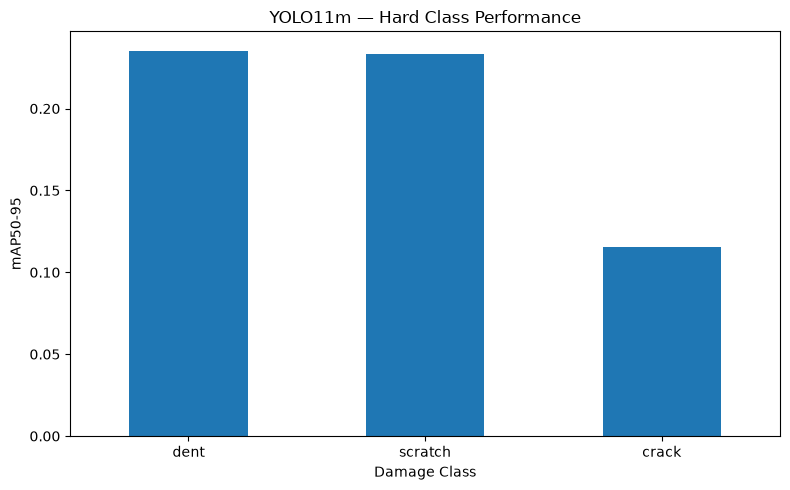

In [66]:
hard_results.plot(
    x="Class",
    y="mAP50-95",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("YOLO11m — Hard Class Performance")
plt.ylabel("mAP50-95")
plt.xlabel("Damage Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

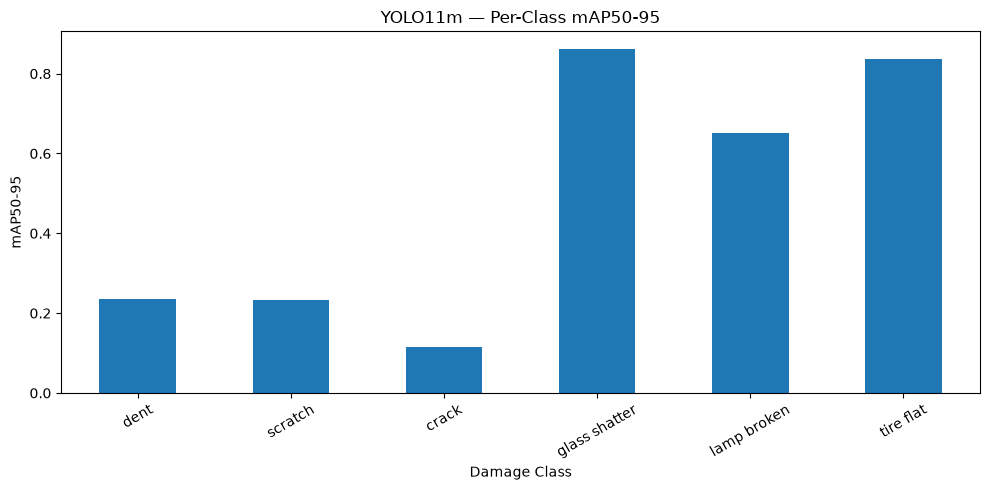

In [68]:
class_df.plot(
    x="Class",
    y="mAP50-95",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("YOLO11m — Per-Class mAP50-95")
plt.ylabel("mAP50-95")
plt.xlabel("Damage Class")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [69]:
RESULTS_CSV = f"{RUNS_ROOT}/{EXP_NAME}/results.csv"

df = pd.read_csv(RESULTS_CSV)

print("Results shape:", df.shape)

df.head()

Results shape: (1, 15)


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,19.3469,0.9844,0.92149,1.25741,0.68302,0.64355,0.6529,0.48932,1.43291,1.59544,1.66892,0.00033,0.00033,0.00033


In [70]:
best_idx = df["metrics/mAP50-95(B)"].idxmax()
best_epoch = df.loc[best_idx]

print("Best Epoch:", int(best_epoch["epoch"]))
print("Precision:", best_epoch["metrics/precision(B)"])
print("Recall:", best_epoch["metrics/recall(B)"])
print("mAP50:", best_epoch["metrics/mAP50(B)"])
print("mAP50-95:", best_epoch["metrics/mAP50-95(B)"])

Best Epoch: 1
Precision: 0.68302
Recall: 0.64355
mAP50: 0.6529
mAP50-95: 0.48932


 epoch  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)
     1               0.68302            0.64355            0.6529              0.48932


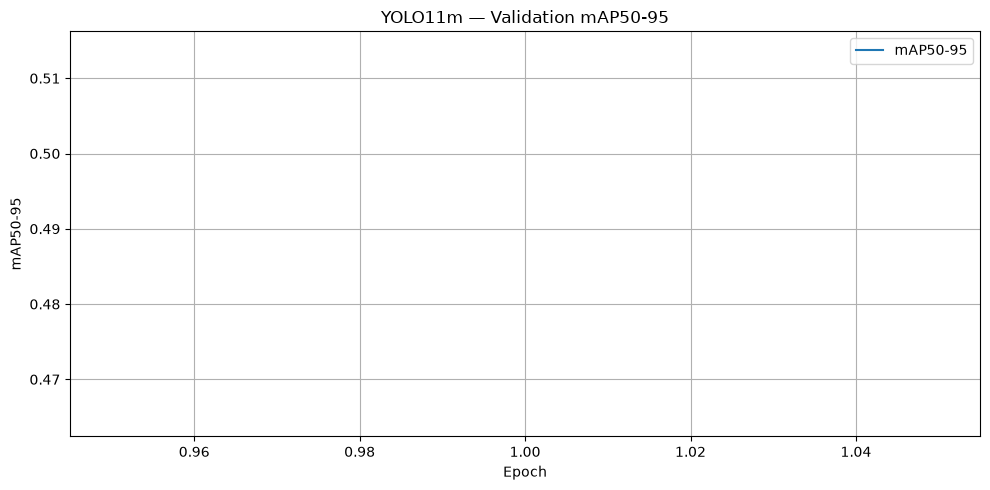

In [72]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["epoch"],
    df["metrics/mAP50-95(B)"],
    label="mAP50-95"

    
)

plt.xlabel("Epoch")
plt.ylabel("mAP50-95")
plt.title("YOLO11m — Validation mAP50-95")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

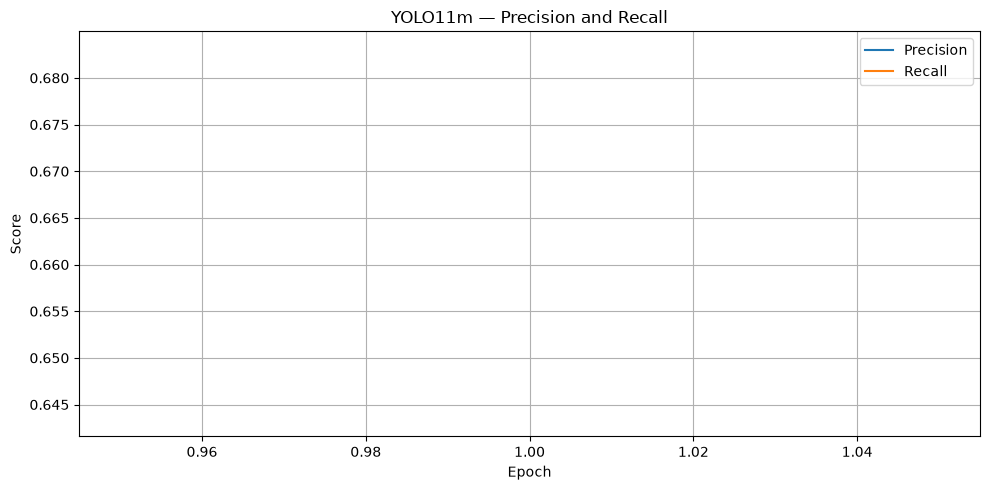

In [73]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["epoch"],
    df["metrics/precision(B)"],
    label="Precision"
)

plt.plot(
    df["epoch"],
    df["metrics/recall(B)"],
    label="Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLO11m — Precision and Recall")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

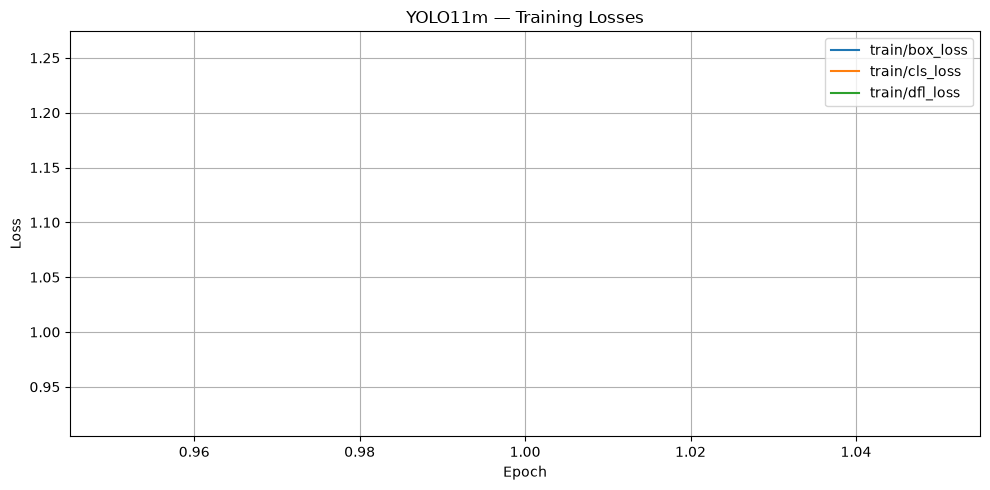

In [74]:
loss_columns = [
    "train/box_loss",
    "train/cls_loss",
    "train/dfl_loss"
]

plt.figure(figsize=(10, 5))

for col in loss_columns:
    if col in df.columns:
        plt.plot(
            df["epoch"],
            df[col],
            label=col
        )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLO11m — Training Losses")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

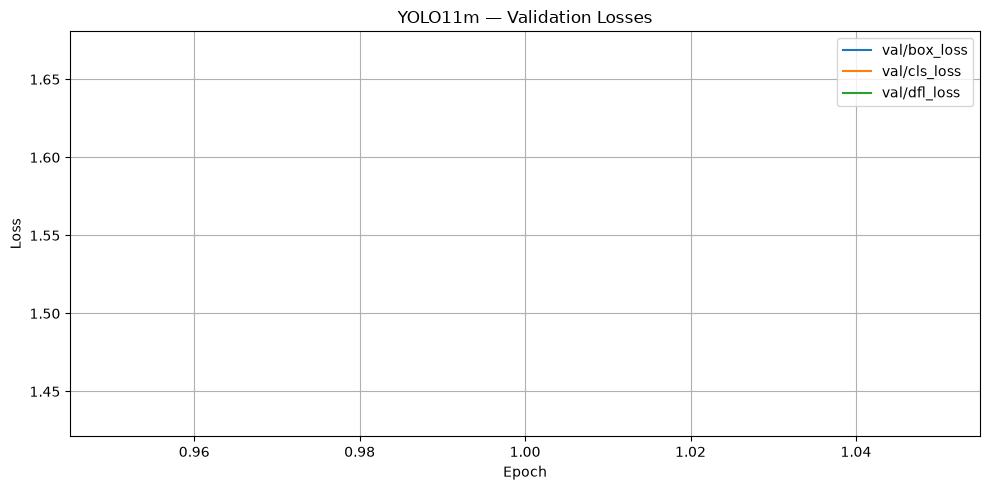

In [75]:
val_loss_columns = [
    "val/box_loss",
    "val/cls_loss",
    "val/dfl_loss"
]

plt.figure(figsize=(10, 5))

for col in val_loss_columns:
    if col in df.columns:
        plt.plot(
            df["epoch"],
            df[col],
            label=col
        )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLO11m — Validation Losses")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [76]:
OUTPUT_DIR = f"{RUNS_ROOT}/experiment_7_analysis"

os.makedirs(OUTPUT_DIR, exist_ok=True)

comparison.to_csv(
    f"{OUTPUT_DIR}/architecture_comparison.csv",
    index=False
)

class_df.to_csv(
    f"{OUTPUT_DIR}/yolo11m_class_results.csv",
    index=False
)

print("Saved analysis files to:")
print(OUTPUT_DIR)

Saved analysis files to:
/workspace/runs/cardd/experiment_7_analysis


In [77]:
print("=" * 60)
print("EXPERIMENT 7 — YOLO11m SUMMARY")
print("=" * 60)

print(f"Precision : {val_results.box.mp:.4f}")
print(f"Recall    : {val_results.box.mr:.4f}")
print(f"mAP50     : {val_results.box.map50:.4f}")
print(f"mAP50-95  : {val_results.box.map:.4f}")

print("\nBest Epoch:")
print(int(best_epoch["epoch"]))

print("\nModel:")
print("YOLO11m")

print("\nDataset:")
print("CarDD Reduced — 1,408 training images")

print("\nTest set:")
print("NOT USED")

EXPERIMENT 7 — YOLO11m SUMMARY
Precision : 0.6798
Recall    : 0.6419
mAP50     : 0.6532
mAP50-95  : 0.4892

Best Epoch:
1

Model:
YOLO11m

Dataset:
CarDD Reduced — 1,408 training images

Test set:
NOT USED


# Exp7-FT — YOLO11m Fine-Tuned

In [78]:
from ultralytics import YOLO
import os

# Exp7 best model
BASE_MODEL = "/workspace/runs/cardd/experiment_7_yolo11m/weights/best.pt"

# Fine-tuning output
FT_NAME = "experiment_7_yolo11m_finetuned"
FT_DIR = f"/workspace/runs/cardd/{FT_NAME}"
FT_BEST = f"{FT_DIR}/weights/best.pt"

print("Base model:", BASE_MODEL)
print("Fine-tuned model:", FT_BEST)

assert os.path.exists(BASE_MODEL), "best.pt not found!"
print("✓ Base model found")

Base model: /workspace/runs/cardd/experiment_7_yolo11m/weights/best.pt
Fine-tuned model: /workspace/runs/cardd/experiment_7_yolo11m_finetuned/weights/best.pt
✓ Base model found


In [79]:
ft_model = YOLO(BASE_MODEL)

print("✓ YOLO11m best checkpoint loaded")
ft_model.info()

✓ YOLO11m best checkpoint loaded
YOLO11m summary: 231 layers, 20,057,634 parameters, 0 gradients, 68.3 GFLOPs


(231, 20057634, 0, 68.3248128)

In [80]:
ft_results = ft_model.train(
    data=DATA_YAML,

    # Fine-tuning
    epochs=30,
    imgsz=640,
    batch=16,

    device=0,
    workers=4,

    # Reproducibility
    seed=42,
    deterministic=True,

    # Lower learning rate for fine-tuning
    lr0=0.0005,
    lrf=0.01,

    # Learning-rate schedule
    cos_lr=True,

    # Early stopping
    patience=10,

    # Same augmentation as Exp7
    degrees=5.0,
    translate=0.15,
    scale=0.60,
    fliplr=0.50,
    flipud=0.0,
    mosaic=1.0,
    mixup=0.10,
    copy_paste=0.10,

    amp=True,

    project=RUNS_ROOT,
    name=FT_NAME,
    exist_ok=True
)

Ultralytics 8.4.153 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA A40, 45488MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/workspace/runs/cardd/experiment_7_yolo11m/weights/best.pt, momentum=0.937, mos

In [81]:
ft_best_model = YOLO(FT_BEST)

print("✓ Fine-tuned model loaded")
ft_best_model.info()

✓ Fine-tuned model loaded
YOLO11m summary: 231 layers, 20,057,634 parameters, 0 gradients, 68.3 GFLOPs


(231, 20057634, 0, 68.3248128)

In [82]:
import os

print("Best model exists:", os.path.exists(FT_BEST))
print("Best model:", FT_BEST)

if os.path.exists(FT_BEST):
    print("✓ Fine-tuned best.pt created successfully")

Best model exists: True
Best model: /workspace/runs/cardd/experiment_7_yolo11m_finetuned/weights/best.pt
✓ Fine-tuned best.pt created successfully


In [83]:
ft_val = ft_best_model.val(
    data=DATA_YAML,
    split="val",
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    plots=True
)

Ultralytics 8.4.153 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA A40, 45488MiB)
YOLO11m summary (fused): 125 layers, 20,034,658 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4513.3±517.6 MB/s, size: 764.5 KB)
val: Scanning /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/labels/val.cache... 810 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 810/810 283.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 8.6it/s 5.9s0.1ss
                   all        810       1744      0.672       0.61      0.615      0.477
                  dent        352        501      0.591      0.385      0.417      0.227
               scratch        431        728      0.404       0.51      0.385      0.194
                 crack        122        177      0.422       0.26      0.226      0.112
         glass shatter        134        135      0.939      0.941       0.97      0.854
      

In [84]:
ft_precision = float(ft_val.box.mp)
ft_recall = float(ft_val.box.mr)
ft_map50 = float(ft_val.box.map50)
ft_map5095 = float(ft_val.box.map)

print("Fine-Tuned YOLO11m")
print("=" * 40)
print(f"Precision : {ft_precision:.4f}")
print(f"Recall    : {ft_recall:.4f}")
print(f"mAP50     : {ft_map50:.4f}")
print(f"mAP50-95  : {ft_map5095:.4f}")

Fine-Tuned YOLO11m
Precision : 0.6723
Recall    : 0.6103
mAP50     : 0.6153
mAP50-95  : 0.4769


In [85]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Experiment": "Exp6 - YOLO11s",
        "Precision": 0.733,
        "Recall": 0.668,
        "mAP50": 0.688,
        "mAP50-95": 0.531
    },
    {
        "Experiment": "Exp7 - YOLO11m",
        "Precision": float(results.results_dict.get("metrics/precision(B)", 0)),
        "Recall": float(results.results_dict.get("metrics/recall(B)", 0)),
        "mAP50": float(results.results_dict.get("metrics/mAP50(B)", 0)),
        "mAP50-95": float(results.results_dict.get("metrics/mAP50-95(B)", 0))
    },
    {
        "Experiment": "Exp7-FT - YOLO11m Fine-Tuned",
        "Precision": ft_precision,
        "Recall": ft_recall,
        "mAP50": ft_map50,
        "mAP50-95": ft_map5095
    }
])

comparison

,Experiment,Precision,Recall,mAP50,mAP50-95
0,Exp6 - YOLO11s,0.733000,0.668000,0.688000,0.531000
1,Exp7 - YOLO11m,0.729467,0.674315,0.692162,0.538674
2,Exp7-FT - YOLO11m Fine-Tuned,0.672292,0.610266,0.615338,0.476935


In [86]:
exp7_row = comparison[
    comparison["Experiment"] == "Exp7 - YOLO11m"
].iloc[0]

ft_row = comparison[
    comparison["Experiment"] == "Exp7-FT - YOLO11m Fine-Tuned"
].iloc[0]

improvement = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP50", "mAP50-95"],
    "Exp7": [
        exp7_row["Precision"],
        exp7_row["Recall"],
        exp7_row["mAP50"],
        exp7_row["mAP50-95"]
    ],
    "Exp7-FT": [
        ft_row["Precision"],
        ft_row["Recall"],
        ft_row["mAP50"],
        ft_row["mAP50-95"]
    ]
})

improvement["Change"] = improvement["Exp7-FT"] - improvement["Exp7"]
improvement["Change (pp)"] = improvement["Change"] * 100

improvement

,Metric,Exp7,Exp7-FT,Change,Change (pp)
0,Precision,0.729467,0.672292,-0.057175,-5.717510
1,Recall,0.674315,0.610266,-0.064048,-6.404841
2,mAP50,0.692162,0.615338,-0.076824,-7.682433
3,mAP50-95,0.538674,0.476935,-0.061739,-6.173905


In [87]:
best_exp = comparison.loc[
    comparison["mAP50-95"].idxmax()
]

print("🏆 Best experiment:")
print(best_exp["Experiment"])
print()
print(f"Precision : {best_exp['Precision']:.4f}")
print(f"Recall    : {best_exp['Recall']:.4f}")
print(f"mAP50     : {best_exp['mAP50']:.4f}")
print(f"mAP50-95  : {best_exp['mAP50-95']:.4f}")

🏆 Best experiment:
Exp7 - YOLO11m

Precision : 0.7295
Recall    : 0.6743
mAP50     : 0.6922
mAP50-95  : 0.5387


In [88]:
from ultralytics import YOLO

FINAL_MODEL_PATH = "/workspace/runs/cardd/experiment_7_yolo11m/weights/best.pt"

final_model = YOLO(FINAL_MODEL_PATH)

print("✓ Final model loaded")

✓ Final model loaded


In [89]:
test_results = final_model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    plots=True,
    project=RUNS_ROOT,
    name="experiment_7_yolo11m_test"
)

print("✓ Test completed")

Ultralytics 8.4.153 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA A40, 45488MiB)
YOLO11m summary (fused): 125 layers, 20,034,658 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3571.0±1742.8 MB/s, size: 914.6 KB)
val: Scanning /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/labels/test... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 435.6it/s 0.9s0.0s
val: New cache created: /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 7.2it/s 3.3s0.1s
                   all        374        785      0.733      0.657      0.685      0.503
                  dent        157        236      0.656        0.5      0.549      0.295
               scratch        183        307      0.493      0.577      0.519      0.272
                 crack         48         70        0.7      0.399      0.434      0.199
      